In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import axes
from typing import Tuple

#load the dataset
import folktexts
from folktexts.acs.acs_tasks import ACSTaskMetadata
from folktexts.acs.acs_dataset import ACSDataset

from pathlib import Path
from folktexts.analysis.setup import ACS_TASKS, LLM_MODELS, baselines
from folktexts.analysis.utils import key_to_model, get_metrics, get_predictions, prettify_model_name, load_baselines, is_instruction_tuned
from folktexts.llm_utils import get_model_size_B

plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR/'overview_results_by_prompt_style.csv'

### Load results

In [3]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df = df[(df['num_shots'] == 0) & (df['prompt_style'] == 'bullet') & (df['prompt_connector'] == 'is')]
df.head()

,task,model,is_inst,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
0,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,862320328,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...
1,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1231502606,0,bullet,is,results/0-bullet-is/model-allenai--OLMo-2-1124...,results/0-bullet-is/model-allenai--OLMo-2-1124...
2,ACSIncome,google--gemma-2-27b,0,3535356034,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b/...,results/0-bullet-is/model-google--gemma-2-27b/...
3,ACSIncome,google--gemma-2-27b-it,1,1373954821,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b-...,results/0-bullet-is/model-google--gemma-2-27b-...
4,ACSIncome,meta-llama--Meta-Llama-3-70B,0,730840778,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...


In [4]:
# load predictions and measured accuracies
predictions = {}
evals = {}

metrics = ['n_samples', 'accuracy', 'fpr', 'num_pred_negatives', 'num_pred_positives']
for task in ACS_TASKS:
    print(task)
    task_df = df[(df['task'] == task)]

    # available models
    models = task_df['model'].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    predictions_per_task = []
    evals[task] = {}
    for m in models: 
        data_m = task_df[task_df['model'] == m]
        assert data_m.shape[0] == 1, f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        evals[task][m] = get_metrics(data_m.iloc[0]['eval_results_path'], metrics=metrics)
        predictions_per_task.append(get_predictions(data_m.iloc[0]['predictions_path']))
    predictions[task] = pd.concat(predictions_per_task, axis=1)

ACSIncome
ACSEmployment
ACSTravelTime
ACSPublicCoverage


In [5]:
# filter to only include non-constant predictors
evals_non_const = {}
for task in ACS_TASKS:
    evals_non_const[task] = {
        key: eval_dict
        for (key, eval_dict) in evals[task].items()
        if not (
            (eval_dict["num_pred_negatives"] == eval_dict["n_samples"])
            or (eval_dict["num_pred_positives"] == eval_dict["n_samples"])
        )
    }

### Load baselines

In [6]:
baselines

{'Constant': DummyClassifier(),
 'LR': LogisticRegression(),
 'GBM': HistGradientBoostingClassifier(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, random_state=None, ...)}

In [7]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=ACS_TASKS)

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSTravelTime.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSTravelTime'.
- LR: Load predictions from 'results/baselines/LR_task-ACSTravelTime'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSTravelTime'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-A

In [8]:
baseline_predictions = {task:baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in ACS_TASKS}
baseline_predictions['ACSIncome'].head()    

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


In [9]:
models_above_baseline = {}
for task in ACS_TASKS:
    print(task)
    baseline_acc = baseline_evals[task]['Constant']['accuracy'] 
    models_above_baseline[task] = [model for model in predictions[task].keys().tolist() if evals[task][model]['accuracy'] > baseline_acc]
    print(len(models_above_baseline[task]))

ACSIncome
18
ACSEmployment
16
ACSTravelTime
12
ACSPublicCoverage
10


### Load data

In [10]:
# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in ACS_TASKS:
    acs_task = ACSTaskMetadata.get_task(task)
    acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
    acs_dataset = ACSDataset.make_from_task(
        task=acs_task, cache_dir=data_dir, **acs_dataset_configs
    )
    X_test, y_test = acs_dataset.get_data_split("test")
    data[task] = (X_test, y_test)

Loading ACS data...
Loading ACS data...
Loading ACS data...
Loading ACS data...


### Plotting

In [11]:
def plot_accuracies(
    ax: axes,
    task: str,
    evals: dict,
    baseline_evals: dict,
    models_above_baseline: dict,
    ylims: Tuple = (0, 0.85),
    label_rotation: int = 50,
    ha: str = "right",
    color: str = "grey",
    highlight_color: str = "black",
    hline_xmin=0,
    hline_xmax=1,  # 
):
    # plot hline for baselines
    ax.hlines(
        baseline_evals[task]["Constant"]["accuracy"],
        xmin=hline_xmin,
        xmax=hline_xmax,
        label="Constant",
        colors="dodgerblue",
        linestyle="-",
        zorder=0,
    )
    ax.hlines(
        baseline_evals[task]["XGBoost"]["accuracy"],
        xmin=hline_xmin,
        xmax=hline_xmax,
        label="XGBoost",
        colors="yellowgreen",
        linestyle="-",
        zorder=0,
    )

    # plot model accuracies
    x_labels = []
    for idx, (model_key, eval_dict) in enumerate(evals[task].items()):
        keep_model = model_key in models_above_baseline[task]
        ax.scatter(
            idx,
            eval_dict["accuracy"],
            zorder=1,
            s=20,
            color="black" if keep_model else "grey",
        )
        x_labels.append(model_key)

    # set xticks
    ax.set_xticks(
        torch.arange(len(x_labels)),
        [prettify_model_name(key_to_model(key)) for key in x_labels],
        rotation=label_rotation,
        ha=ha,
        color=color,
    )
    for m in x_labels:
        if m in models_above_baseline[task]:
            idx = x_labels.index(m)
            plt.setp(ax.get_xticklabels()[idx], color=highlight_color)
    ax.set_ylim(ylims)
    ax.set_xlim(right=len(x_labels))

    return ax


def plot_label_dist(
    ax: axes, labels: pd.Series, ylims: Tuple = (0, 0.75), bar_width=0.2
):
    counts = labels.value_counts()
    ax.bar(
        counts.index * 2 * bar_width, counts.values / labels.shape[0], width=bar_width
    )
    ax.set_xticks(ticks=counts.index * 2 * bar_width, labels=counts.index)
    ax.set_xlabel("$y$")
    ax.set_ylim(ylims)
    return ax


def plot_neg_predicted(
    ax: axes,
    task: str,
    evals: dict,
    models_above_baseline: dict,
    ylims=(0, 1),
    label_rotation: int = 50,
    ha: str = "right",
    color: str = "grey",
    highlight_color: str = "black",
    omit_non_highlight_labels=False,
    bar_width=0.5,
):
    x_labels = []
    for idx, (model_key, eval_dict) in enumerate(evals[task].items()):
        keep_model = model_key in models_above_baseline[task]
        ax.bar(
            idx,
            eval_dict["num_pred_negatives"] / eval_dict["n_samples"],
            # width=bar_width,
            zorder=1,
            color="black" if keep_model else "grey",
        )
        x_labels.append(model_key)

    # set xticks
    if not omit_non_highlight_labels:
        ax.set_xticks(
            torch.arange(len(x_labels)),
            [prettify_model_name(key_to_model(key)) for key in x_labels],
            rotation=label_rotation,
            ha=ha,
            color=color,
        )
        for m in x_labels:
            if m in models_above_baseline[task]:
                idx = x_labels.index(m)
                plt.setp(ax.get_xticklabels()[idx], color=highlight_color)
    else:
        ax.set_xticks(
            torch.arange(len(x_labels)),
            [
                (
                    prettify_model_name(key_to_model(key))
                    if key in models_above_baseline[task]
                    else ""
                )
                for key in x_labels
            ],
            rotation=label_rotation,
            ha=ha,
            color=highlight_color,
        )
    ax.set_ylim(ylims)
    ax.set_xlim(right=len(x_labels))

    return ax

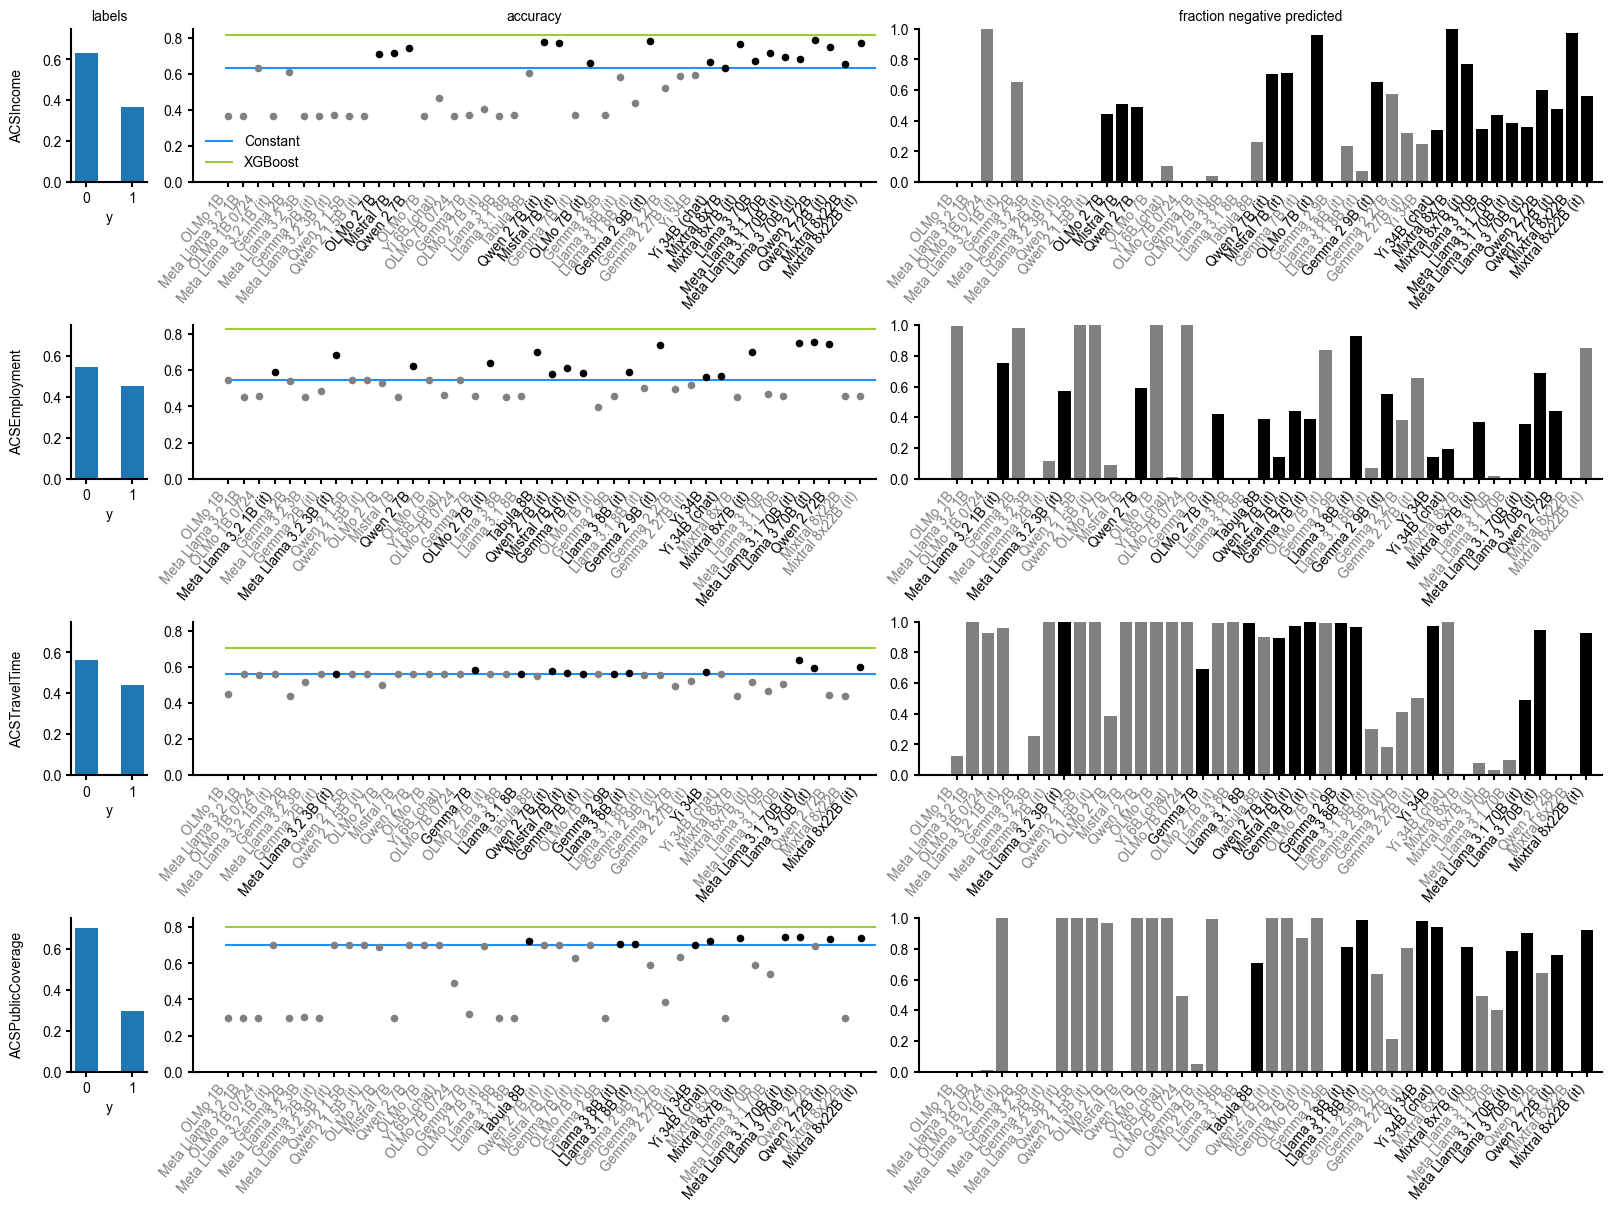

In [12]:
tasks = [task for task in ACS_TASKS if task != 'ACSMobility']
fig, axs = plt.subplots(len(tasks), 3, figsize=(16, 3*len(tasks)), constrained_layout=True, gridspec_kw={'width_ratios': [1,9,9]})
axs[0, 0].set_title("labels")
axs[0, 1].set_title("accuracy")
axs[0, 2].set_title("fraction negative predicted")
pad = 5 #pt

for i, task in enumerate(tasks):
    axs[i,0].annotate(task, xy=(0, 0.5), xytext=(-axs[i,0].yaxis.labelpad - pad, 0), xycoords=axs[i,0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center', rotation=90)

    # label distribution
    labels = data[task][1]
    axs[i,0] = plot_label_dist(axs[i,0], labels, ylims=(0,0.75))

    # model accuracy
    axs[i,1] = plot_accuracies(ax=axs[i,1], task=task, evals=evals, baseline_evals=baseline_evals, models_above_baseline=models_above_baseline, ylims=(0,0.85), hline_xmin=-0.2, hline_xmax=predictions[task].shape[1] + 0.1,)
    
    # fraction of negative predicted samples
    axs[i,2] = plot_neg_predicted(axs[i,2], task=task, evals=evals, models_above_baseline=models_above_baseline,)
    
    axs[0,1].legend()
plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_model_performance.png')
plt.show()

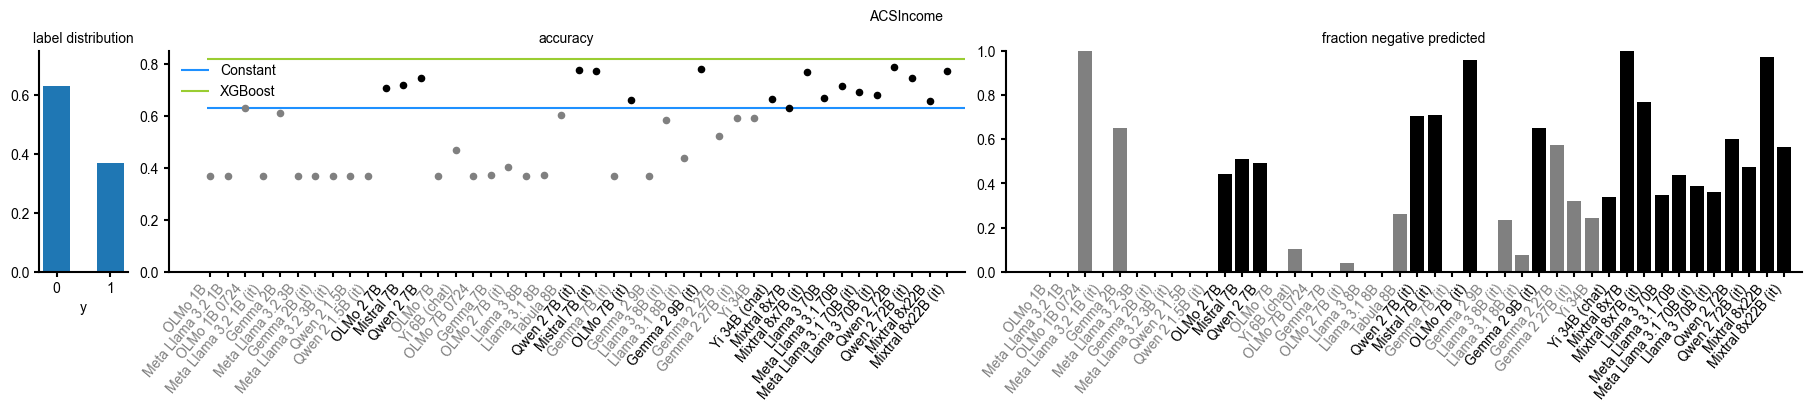

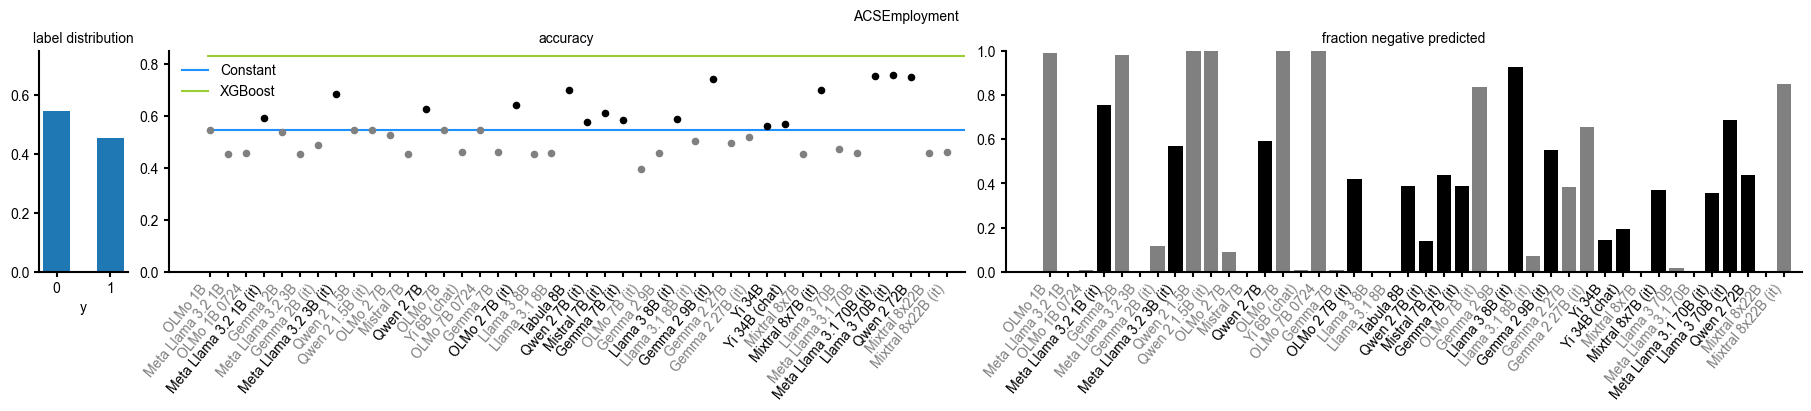

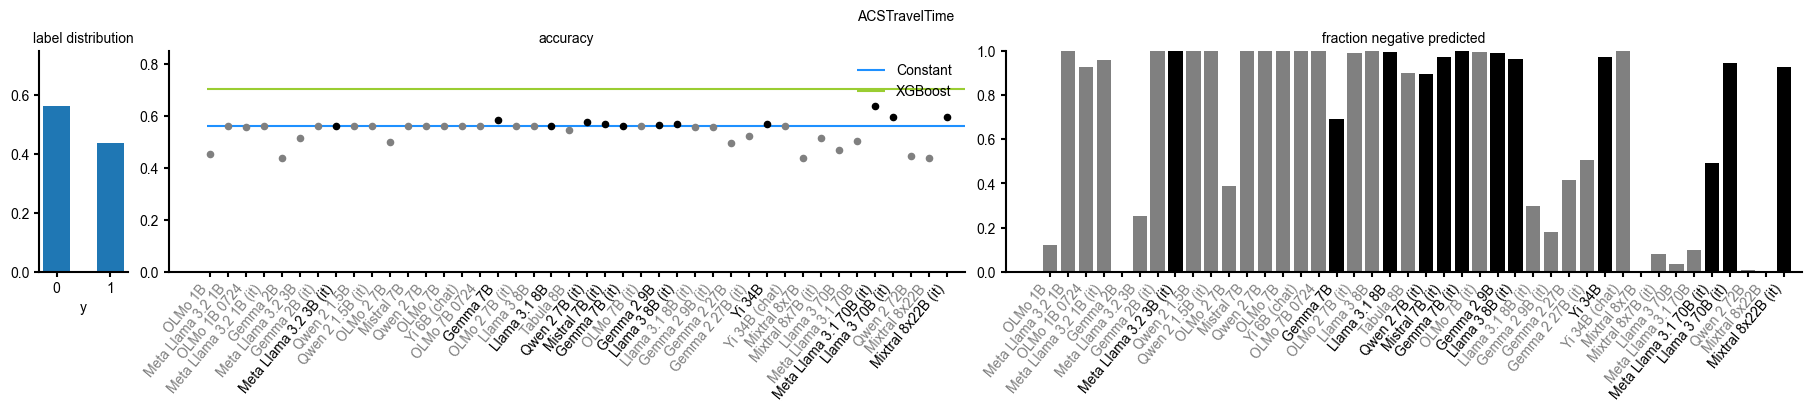

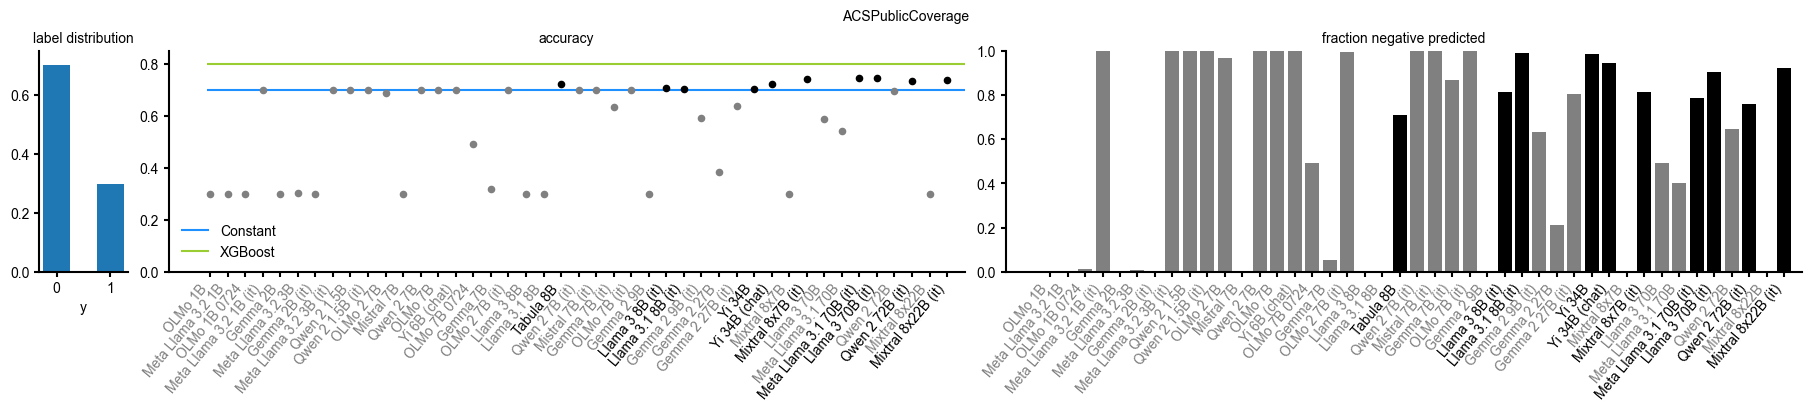

In [13]:
for task in ACS_TASKS:
    fig, axs = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True, gridspec_kw={'width_ratios': [1,9,9]})
    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    axs[2].set_title("fraction negative predicted")
    pad = 5 #pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=(0,0.75))

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(ax=axs[1], task=task, evals=evals, baseline_evals=baseline_evals, models_above_baseline=models_above_baseline, ylims=(0,0.85), hline_xmin=-0.2, hline_xmax=predictions[task].shape[1] + 0.1,)
    
    # fraction of negative predicted samples
    axs[2] = plot_neg_predicted(axs[2], task=task, evals=evals, models_above_baseline=models_above_baseline, omit_non_highlight_labels=False)
    
    axs[1].legend()
    plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_model_performance_{task}.png')
    plt.show()